# 03. Deep Sequence Models on Chosen Series

This notebook reuses the representative `chosen` selection from `01_eda.ipynb`, then trains target-only recurrent neural networks on those four series with an 80/20 split:

- vanilla RNN
- LSTM
- GRU

Validation uses one-step windows built from the last training window plus the observed validation history, matching the corrected sequence-evaluation code.


## 0. Environment Check

Run this first. The local `af` virtual environment and the Homebrew Jupyter kernel may not have a working `torch`/parquet stack, so this cell prints the active interpreter and imports the packages this notebook needs.


In [1]:
import os
import sys
import importlib
from pathlib import Path

# Keep matplotlib/font caches out of unwritable home directories when possible.
os.environ.setdefault('MPLCONFIGDIR', str(Path('/tmp') / 'matplotlib-cache'))
os.environ.setdefault('XDG_CACHE_HOME', str(Path('/tmp') / 'xdg-cache'))

print('Python executable:', sys.executable)
print('Python version:   ', sys.version.replace('\n', ' '))

required_modules = ['pandas', 'pyarrow', 'numpy', 'matplotlib', 'sklearn', 'torch']
versions = {}
missing = []
for module_name in required_modules:
    try:
        module = importlib.import_module(module_name)
        versions[module_name] = getattr(module, '__version__', 'ok')
    except Exception as exc:
        versions[module_name] = f'MISSING: {type(exc).__name__}: {exc}'
        missing.append(module_name)

for module_name, version in versions.items():
    print(f'{module_name:>10}: {version}')

if missing:
    raise ImportError(
        'This notebook needs the missing modules above. In this workspace the known-good '
        'interpreter is /Library/Frameworks/Python.framework/Versions/3.12/bin/python3.'
    )


Python executable: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/.venv/bin/python
Python version:    3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]
    pandas: 3.0.2
   pyarrow: 24.0.0
     numpy: 2.4.4
matplotlib: 3.10.9
   sklearn: 1.8.0
     torch: 2.11.0


## 1. Setup and Data Load

Only the columns needed for target-only sequence modeling are loaded from `train.parquet`.


In [2]:
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch import nn

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'ts-forecasting'
VAL_CUTOFF = 2880
SEED = 42

series_keys = ['code', 'sub_code', 'sub_category', 'horizon']
required_columns = [*series_keys, 'ts_index', 'y_target', 'weight']

SEQ_LEN = 20
HIDDEN_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.01
ARCHITECTURES = ['RNN', 'LSTM', 'GRU']
SMOKE_TEST = os.environ.get('NOTEBOOK_SMOKE', '0') == '1'

DEVICE = torch.device('cpu')
print('PROJECT_ROOT:', PROJECT_ROOT)
print('DATA_DIR:    ', DATA_DIR)
print('Device:      ', DEVICE)


PROJECT_ROOT: /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting
DATA_DIR:     /Users/kaushalnandaniya/Desktop/MnC/sem-6/AF/HedgeFund_TimeSeriesForcasting/data/ts-forecasting
Device:       cpu


In [3]:
def set_all_seeds(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

set_all_seeds(SEED)
torch.set_num_threads(max(1, min(4, os.cpu_count() or 1)))

train = pd.read_parquet(DATA_DIR / 'train.parquet', columns=required_columns)
train = train.sort_values(series_keys + ['ts_index']).reset_index(drop=True)

print(f'Train shape: {train.shape}')
print(f'Train ts_index range: {int(train.ts_index.min())} to {int(train.ts_index.max())}')
print(f'Loaded columns: {required_columns}')
train.head()


Train shape: (5337414, 7)
Train ts_index range: 1 to 3601
Loaded columns: ['code', 'sub_code', 'sub_category', 'horizon', 'ts_index', 'y_target', 'weight']


,code,sub_code,sub_category,horizon,ts_index,y_target,weight
0,10BAVIDU,236HB58W,DPPUO5X2,1,3531,-2.795824,0.032189
1,10BAVIDU,236HB58W,DPPUO5X2,1,3532,-1.250105,0.032876
2,10BAVIDU,236HB58W,DPPUO5X2,1,3533,4.685167,0.032329
3,10BAVIDU,236HB58W,DPPUO5X2,1,3534,-0.159681,0.033005
4,10BAVIDU,236HB58W,DPPUO5X2,1,3535,-1.256449,0.033736


## 2. Recreate `chosen`

This is the same representative-series logic from the EDA notebook: longest history, highest total weight, most volatile, and most stable among eligible series.


In [4]:
series_stats = (
    train.groupby(series_keys)
         .agg(length=('ts_index', 'size'),
              start=('ts_index', 'min'),
              end=('ts_index', 'max'),
              total_weight=('weight', 'sum'),
              target_std=('y_target', 'std'))
         .reset_index()
)
series_stats['crosses_cutoff'] = (series_stats['start'] <= VAL_CUTOFF) & (series_stats['end'] > VAL_CUTOFF)

eligible = series_stats[(series_stats['crosses_cutoff']) & (series_stats['length'] >= 120)].copy()
eligible['target_std'] = eligible['target_std'].fillna(0.0)
stable_pool = eligible[eligible['target_std'] > 0]

chosen = pd.concat([
    eligible.nlargest(1, 'length').assign(reason='longest history'),
    eligible.nlargest(1, 'total_weight').assign(reason='highest total weight'),
    eligible.nlargest(1, 'target_std').assign(reason='most volatile'),
    stable_pool.nsmallest(1, 'target_std').assign(reason='most stable'),
], ignore_index=True).drop_duplicates(subset=series_keys)

print(f'Total series: {len(series_stats):,}')
print(f'Eligible series: {len(eligible):,}')
chosen[[*series_keys, 'reason', 'length', 'start', 'end', 'total_weight', 'target_std']]


Total series: 36,923
Eligible series: 1,576


,code,sub_code,sub_category,horizon,reason,length,start,end,total_weight,target_std
0,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,longest history,212,2826,3037,9.060035e+02,2.641558
1,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,highest total weight,156,2874,3032,4.349747e+10,0.000394
2,W4S29LF4,KL66VIS3,PHHHVYZI,25,most volatile,162,2747,2911,4.562944e-01,296.760011
3,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,most stable,170,2874,3052,3.869062e+10,0.000139


In [5]:
def series_label(row):
    return f"{row['code']}_{row['sub_code']}_{row['sub_category']}_H{int(row['horizon'])}"

chosen = chosen.copy()
chosen['series'] = chosen.apply(series_label, axis=1)

chosen[[
    'series', *series_keys, 'reason', 'length', 'start', 'end', 'total_weight', 'target_std'
]].sort_values('reason')


,series,code,sub_code,sub_category,horizon,reason,length,start,end,total_weight,target_std
1,SJZP0OVU_OYJGNSQK_NQ58FVQM_H25,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,highest total weight,156,2874,3032,4.349747e+10,0.000394
0,X9BZ68VQ_OYJGNSQK_DPPUO5X2_H1,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,longest history,212,2826,3037,9.060035e+02,2.641558
3,SJZP0OVU_OYJGNSQK_NQ58FVQM_H1,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,most stable,170,2874,3052,3.869062e+10,0.000139
2,W4S29LF4_KL66VIS3_PHHHVYZI_H25,W4S29LF4,KL66VIS3,PHHHVYZI,25,most volatile,162,2747,2911,4.562944e-01,296.760011


## 3. Metrics and Series Utilities

The metrics below report unweighted RMSE/MAE/R2 plus the weighted skill score used elsewhere in the project.


In [6]:
def weighted_rmse_score(y_true, y_pred, weights):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weights = np.asarray(weights, dtype=float)

    denom = np.sum(weights * (y_true ** 2))
    if denom == 0:
        return np.nan

    ratio = np.sum(weights * ((y_true - y_pred) ** 2)) / denom
    ratio = np.clip(float(ratio), 0.0, 1.0)
    return float(np.sqrt(1.0 - ratio))


def compute_metrics(y_true, y_pred, weights):
    return {
        'rmse': np.sqrt(mean_squared_error(y_true, y_pred)),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2': r2_score(y_true, y_pred),
        'skill': weighted_rmse_score(y_true, y_pred, weights),
    }


In [7]:
def get_series(df, row, series_keys):
    mask = np.ones(len(df), dtype=bool)
    for key in series_keys:
        mask &= df[key].eq(row[key]).to_numpy()

    subset = df.loc[mask].sort_values('ts_index')
    series = subset['y_target'].to_numpy(dtype=float)
    weights = subset['weight'].to_numpy(dtype=float)
    return series, weights


def split_80_20(series):
    split = int(len(series) * 0.8)
    return series[:split], series[split:]


split_rows = []
for _, row in chosen.iterrows():
    series, weights = get_series(train, row, series_keys)
    train_s, val_s = split_80_20(series)
    _, val_w = split_80_20(weights)
    split_rows.append({
        'series': row['series'],
        'reason': row['reason'],
        'length': len(series),
        'train_len': len(train_s),
        'val_len': len(val_s),
        'val_weight_sum': float(np.sum(val_w)),
    })

split_summary = pd.DataFrame(split_rows)
split_summary


,series,reason,length,train_len,val_len,val_weight_sum
0,X9BZ68VQ_OYJGNSQK_DPPUO5X2_H1,longest history,212,169,43,2.108887e+02
1,SJZP0OVU_OYJGNSQK_NQ58FVQM_H25,highest total weight,156,124,32,1.303507e+10
2,W4S29LF4_KL66VIS3_PHHHVYZI_H25,most volatile,162,129,33,1.296214e-01
3,SJZP0OVU_OYJGNSQK_NQ58FVQM_H1,most stable,170,136,34,1.114047e+10


## 4. Windowing and Model Definition

Training uses one-step supervised windows of length `SEQ_LEN = 20`. Validation predictions are produced over `train[-SEQ_LEN:] + validation`, so each validation step uses the observed previous values in its input window.


In [8]:
def create_sequences(series, seq_len=SEQ_LEN):
    X, y = [], []
    for i in range(len(series) - seq_len):
        X.append(series[i:i + seq_len])
        y.append(series[i + seq_len])
    return np.array(X), np.array(y)


class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])


class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=HIDDEN_SIZE):
        super().__init__()
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.fc(out[:, -1, :])


In [9]:
def train_model(model, X, y, epochs=EPOCHS):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_fn = nn.MSELoss()

    X_t = torch.tensor(X, dtype=torch.float32, device=DEVICE).unsqueeze(-1)
    y_t = torch.tensor(y, dtype=torch.float32, device=DEVICE)

    for _ in range(epochs):
        optimizer.zero_grad()
        preds = model(X_t).squeeze(-1)
        loss = loss_fn(preds, y_t)
        loss.backward()
        optimizer.step()

    return model


def predict_model(model, series, seq_len=SEQ_LEN):
    model.eval()
    preds = []

    for i in range(len(series) - seq_len):
        x = (
            torch.tensor(series[i:i + seq_len], dtype=torch.float32, device=DEVICE)
            .unsqueeze(0)
            .unsqueeze(-1)
        )

        with torch.no_grad():
            pred = model(x).item()

        preds.append(pred)

    return np.array(preds)


## 5. Train, Plot, and Evaluate

Each chosen series is normalized with training statistics only, trained with RNN/LSTM/GRU, then transformed back to the original `y_target` scale before plotting and scoring.


[1/4] X9BZ68VQ_OYJGNSQK_DPPUO5X2_H1 (longest history): train=169, val=43


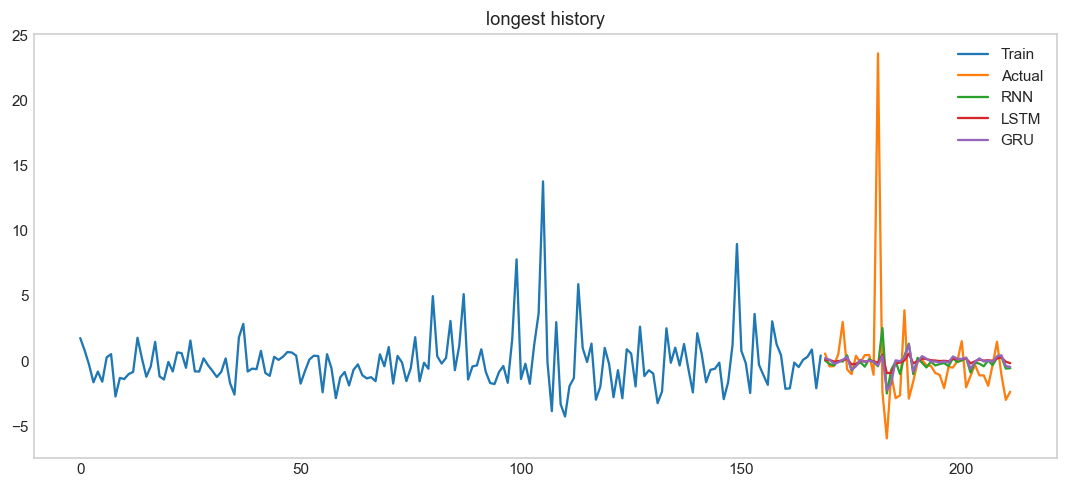

[2/4] SJZP0OVU_OYJGNSQK_NQ58FVQM_H25 (highest total weight): train=124, val=32


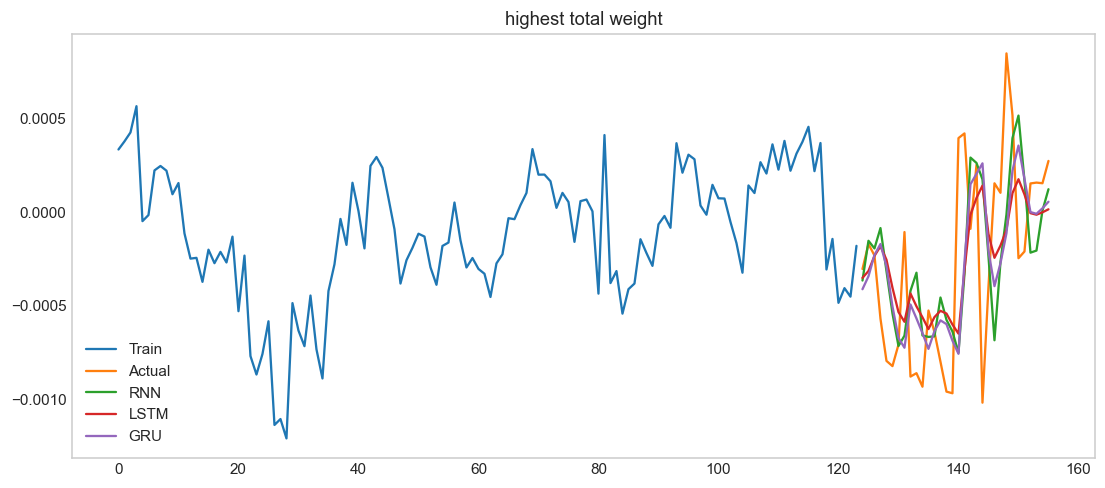

[3/4] W4S29LF4_KL66VIS3_PHHHVYZI_H25 (most volatile): train=129, val=33


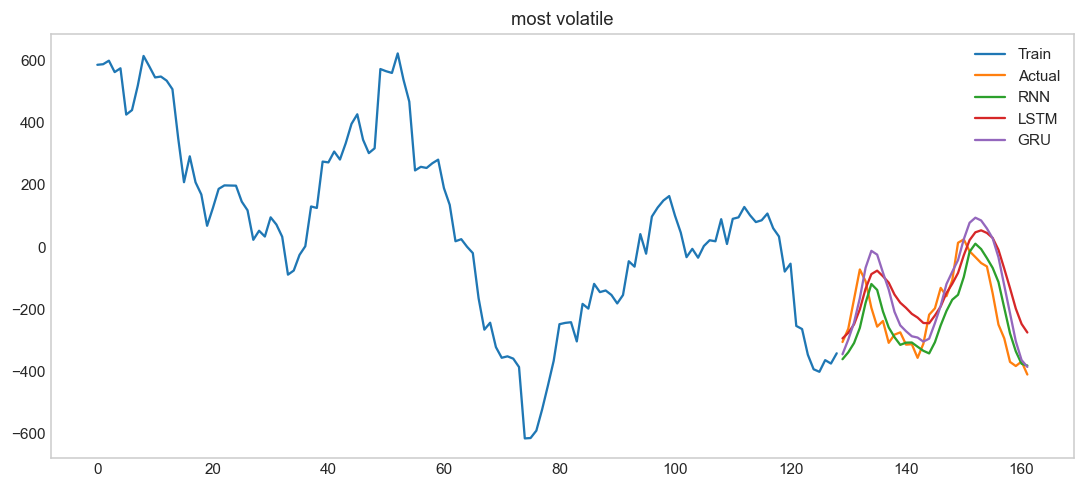

[4/4] SJZP0OVU_OYJGNSQK_NQ58FVQM_H1 (most stable): train=136, val=34


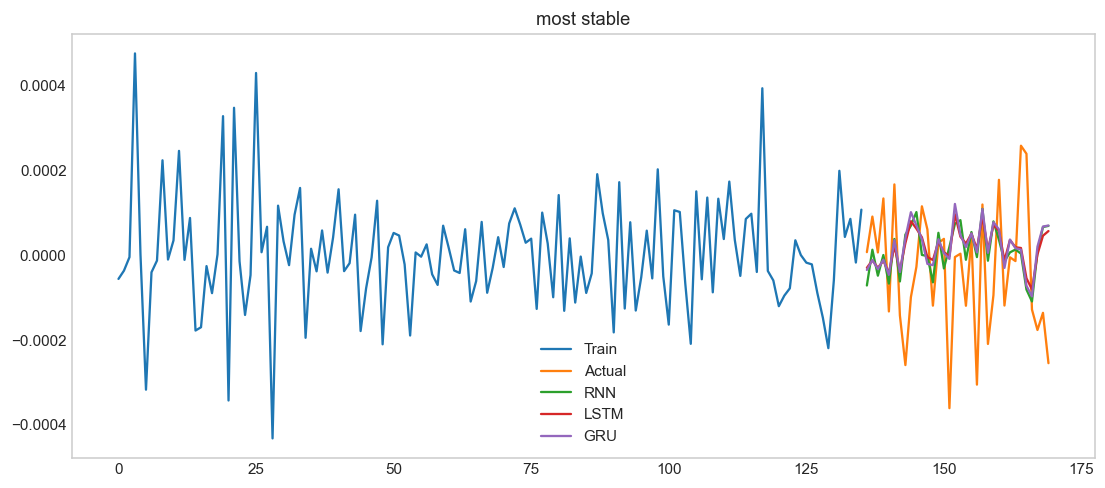

              Series Model     RMSE      MAE      R2  Skill
highest total weight   RNN   0.0005   0.0004  0.0489 0.5062
highest total weight  LSTM   0.0005   0.0004  0.2125 0.6194
highest total weight   GRU   0.0005   0.0004  0.1399 0.5712
     longest history   GRU   3.9979   1.7771  0.0028 0.0562
     longest history  LSTM   4.0025   1.8179  0.0005 0.0389
     longest history   RNN   4.0224   1.7136 -0.0095 0.0000
         most stable   RNN   0.0002   0.0001 -0.2173 0.0000
         most stable  LSTM   0.0002   0.0001 -0.1722 0.0000
         most stable   GRU   0.0002   0.0001 -0.2180 0.0000
       most volatile   RNN  84.8725  69.2437  0.5172 0.9371
       most volatile   GRU 108.2003  87.1790  0.2153 0.8944
       most volatile  LSTM 124.0341 104.5639 -0.0312 0.8584


In [10]:
experiment_series = chosen.head(1).copy() if SMOKE_TEST else chosen.copy()
results = []
forecast_store = {}
split_store = {}
seq_len = SEQ_LEN

model_classes = {
    'RNN': RNNModel,
    'LSTM': LSTMModel,
    'GRU': GRUModel,
}

for series_idx, (_, row) in enumerate(experiment_series.iterrows(), start=1):
    series, weights = get_series(train, row, series_keys)
    train_s, val_s = split_80_20(series)
    _, val_w = split_80_20(weights)
    series_id = row['series']
    split_store[series_id] = (train_s, val_s)

    print(f"[{series_idx}/{len(experiment_series)}] {series_id} ({row['reason']}): train={len(train_s)}, val={len(val_s)}")

    if len(train_s) <= seq_len or len(val_s) == 0:
        print(f'  skipped: not enough data for seq_len={seq_len}')
        continue

    # Normalize with train only so validation remains truly held out.
    mean = train_s.mean()
    std = train_s.std() + 1e-8

    train_s_norm = (train_s - mean) / std
    val_s_norm = (val_s - mean) / std

    X_train, y_train = create_sequences(train_s_norm, seq_len)
    preds_dict = {}

    for name, model_class in model_classes.items():
        set_all_seeds(SEED)
        model = model_class().to(DEVICE)
        model = train_model(model, X_train, y_train)

        full_series = np.concatenate([train_s_norm[-seq_len:], val_s_norm])
        preds_norm = predict_model(model, full_series, seq_len)
        preds = preds_norm * std + mean
        preds = preds[-len(val_s):]

        preds_dict[name] = preds
        forecast_store[(series_id, name)] = preds

    plt.figure(figsize=(12, 5))
    plt.plot(train_s, label='Train')
    plt.plot(range(len(train_s), len(series)), val_s, label='Actual')

    for name, preds in preds_dict.items():
        plt.plot(range(len(train_s), len(series)), preds, label=name)

    plt.title(row['reason'])
    plt.legend()
    plt.grid()
    plt.show()

    for name, preds in preds_dict.items():
        m = compute_metrics(val_s, preds, val_w)
        results.append({
            'Series': row['reason'],
            'Model': name,
            'RMSE': m['rmse'],
            'MAE': m['mae'],
            'R2': m['r2'],
            'Skill': m['skill'],
        })

results_df = pd.DataFrame(results).round(4)
print(results_df.sort_values(['Series', 'RMSE']).to_string(index=False))


## 6. Sorted Results

Lower RMSE/MAE is better; higher R2/Skill is better.


In [11]:
results_df.sort_values(['Series', 'RMSE']).reset_index(drop=True)


,Series,Model,RMSE,MAE,R2,Skill
0,highest total weight,RNN,0.0005,0.0004,0.0489,0.5062
1,highest total weight,LSTM,0.0005,0.0004,0.2125,0.6194
2,highest total weight,GRU,0.0005,0.0004,0.1399,0.5712
3,longest history,GRU,3.9979,1.7771,0.0028,0.0562
4,longest history,LSTM,4.0025,1.8179,0.0005,0.0389
5,longest history,RNN,4.0224,1.7136,-0.0095,0.0000
6,most stable,RNN,0.0002,0.0001,-0.2173,0.0000
7,most stable,LSTM,0.0002,0.0001,-0.1722,0.0000
8,most stable,GRU,0.0002,0.0001,-0.2180,0.0000
9,most volatile,RNN,84.8725,69.2437,0.5172,0.9371
